# Análise de depressão 


## Preparação dos dados

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from IPython.display import display

from preparar_dados import criar_dados_descritivos

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_rows", 300)
pd.set_option("display.float_format", lambda valor: f"{valor:,.3f}")

arquivo_2019 = "pns2019.csv"

In [8]:
base = pd.read_csv(arquivo_2019)

display(base.head())
display(base.shape)


,V0001,V0024,UPA_PNS,V0006_PNS,V0015,V0020,V0022,V0026,V0031,V0025A,V0025B,A001,A002010,A003010,A004010,A01001,A011,A005010,A005012,A00601,A009010,A01401,A01402,A01403,A01501,A016010,A018011,A018012,A018013,A018014,A018015,A018016,A018017,A018018,A018019,A018020,A018021,A018022,A018023,A018024,A018025,A018026,A018027,A018028,A01901,A02101,A02102,A02201,A02305,A02306,A02307,A02308,A02401,A02402,B001,B002,B003,B004,C001,C00301,C004,C006,C00701,C00702,C00703,C008,C009,C01001,C010010,C013,C014,C015,C016,C017,C018,C01801,C011,C012,D001,D00201,D00202,D00301,D00501,D006,D00601,D007,D008,D00901,D010,D01101,...,V034,V03501,V03502,V03503,V036,V037,V038,V039,T001,T002,T003,T004,T005,T00601,T00602,T00603,T00604,T00605,T00606,Y001,Y00101,Y002,Y003,Y004,Y005,Y006,Y007,H001,H002,H003,H004,H005,H006,H007,H008,H009,H010,H011,H012,H013,H014,H015,H016,H017,H018,H019,H020,H021,H022,H023,H024,H025,H026,H027,H028,H029,H030,W001,W00101,W00102,W00103,W00201,W00202,W00203,V0028,V0029,V0030,V00281,V00291,V00301,V00282,V00292,V00302,V00283,V00293,V00303,VDC001,VDC003,VDD004A,VDE001,VDE002,VDE014,VDF002,VDF003,VDF004,VDL001,VDM001,VDP001,VDR001,VDDATA
0,11,1110011,110000016,1,1,2019,6.000,1,1,1.000,NaN,1.000,1.000,1.000,1.000,5.000,2.000,1.000,NaN,1.000,1.000,2.000,NaN,NaN,4.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,2.000,NaN,1.000,1.000,2.000,NaN,2.000,NaN,2.000,NaN,2.000,NaN,1.000,2.000,NaN,1.000,0.000,2.000,0.000,0.000,NaN,0.000,1.000,4.000,4.000,5.000,6.000,1.000,1.000,2.000,22.000,11.000,"1,963.000",55.000,1.000,1.000,2.000,NaN,2.000,1.000,2.000,NaN,1.000,17.000,1.000,1.000,1.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,1.000,5.000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,2.000,2.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,17.000,1.000,3.000,NaN,2.000,3.000,1.000,2.000,2.000,2.000,1.000,1.000,1.000,1.000,1.000,1.000,3.000,4.000,4.000,4.000,1.000,2.000,NaN,NaN,NaN,NaN,1.000,1.000,1.000,1.000,4.000,4.000,4.000,4.000,1.000,4.000,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85.589,256.767,NaN,118.312,368.875,NaN,"529,479.000","69,788.655",NaN,111.000,"11,124.000",NaN,6.000,3.000,2.000,1.000,1.000,6.000,"2,098.000",350.000,2.000,NaN,NaN,NaN,NaN,20210825
1,11,1110011,110000016,1,1,2019,6.000,1,1,0.000,NaN,1.000,1.000,1.000,1.000,5.000,2.000,1.000,NaN,1.000,1.000,2.000,NaN,NaN,4.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,2.000,NaN,1.000,1.000,2.000,NaN,2.000,NaN,2.000,NaN,2.000,NaN,1.000,2.000,NaN,1.000,0.000,2.000,0.000,0.000,NaN,0.000,1.000,4.000,4.000,5.000,6.000,2.000,2.000,1.000,8.000,4.000,"1,950.000",69.000,4.000,1.000,1.000,NaN,2.000,1.000,2.000,NaN,1.000,30.000,1.000,2.000,1.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,2.000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85.589,NaN,NaN,118.312,NaN,NaN,"529,479.000",NaN,NaN,111.000,NaN,NaN,6.000,3.000,1.000,2.000,NaN,NaN,"2,098.000",350.000,2.000,NaN,NaN,NaN,NaN,20210825
2,11,1110011,110000016,1,1,2019,6.000,1,1,0.000,NaN,1.000,1.000,1.000,1.000,5.000,2.000,1.000,NaN,1.000,1.000,2.000,NaN,NaN,4.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,2.000,NaN,1.000,1.000,2.000,NaN,2.000,NaN,2.000,NaN,2.000,NaN,1.000,2.000,NaN,1.000,0.000,2.000,0.000,0.000,NaN,0.000,1.000,4.000,4.000,5.000,6.000,3.000,6.000,1.000,13.000,9.000,"1,987.000",31.000,2.000,2.000,NaN,2.000,NaN,NaN,NaN,1.000,2.000,NaN,4.000,2.000,1.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,1.000,10.000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85.589,NaN,NaN,118.312,NaN,NaN,"529,479.000",NaN,NaN,111.000,NaN,NaN,6.000,3.000,5.000,1.000,1.000,4.000,"2,098.000",350.000,2.000,NaN,NaN,NaN,NaN,20210825
3,11,1110011,110000016,1,1,2019,6.00

(293726, 1087)

## Seleção da população adulta

In [9]:
base_adultos = base[(base["V0025A"] == 1) & (base["C008"] >= 18) ]

display(base_adultos.shape)
display(base_adultos.head())

(91683, 1087)

,V0001,V0024,UPA_PNS,V0006_PNS,V0015,V0020,V0022,V0026,V0031,V0025A,V0025B,A001,A002010,A003010,A004010,A01001,A011,A005010,A005012,A00601,A009010,A01401,A01402,A01403,A01501,A016010,A018011,A018012,A018013,A018014,A018015,A018016,A018017,A018018,A018019,A018020,A018021,A018022,A018023,A018024,A018025,A018026,A018027,A018028,A01901,A02101,A02102,A02201,A02305,A02306,A02307,A02308,A02401,A02402,B001,B002,B003,B004,C001,C00301,C004,C006,C00701,C00702,C00703,C008,C009,C01001,C010010,C013,C014,C015,C016,C017,C018,C01801,C011,C012,D001,D00201,D00202,D00301,D00501,D006,D00601,D007,D008,D00901,D010,D01101,...,V034,V03501,V03502,V03503,V036,V037,V038,V039,T001,T002,T003,T004,T005,T00601,T00602,T00603,T00604,T00605,T00606,Y001,Y00101,Y002,Y003,Y004,Y005,Y006,Y007,H001,H002,H003,H004,H005,H006,H007,H008,H009,H010,H011,H012,H013,H014,H015,H016,H017,H018,H019,H020,H021,H022,H023,H024,H025,H026,H027,H028,H029,H030,W001,W00101,W00102,W00103,W00201,W00202,W00203,V0028,V0029,V0030,V00281,V00291,V00301,V00282,V00292,V00302,V00283,V00293,V00303,VDC001,VDC003,VDD004A,VDE001,VDE002,VDE014,VDF002,VDF003,VDF004,VDL001,VDM001,VDP001,VDR001,VDDATA
0,11,1110011,110000016,1,1,2019,6.000,1,1,1.000,NaN,1.000,1.000,1.000,1.000,5.000,2.000,1.000,NaN,1.000,1.000,2.000,NaN,NaN,4.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,2.000,NaN,1.000,1.000,2.000,NaN,2.000,NaN,2.000,NaN,2.000,NaN,1.000,2.000,NaN,1.000,0.000,2.000,0.000,0.000,NaN,0.000,1.000,4.000,4.000,5.000,6.000,1.000,1.000,2.000,22.000,11.000,"1,963.000",55.000,1.000,1.000,2.000,NaN,2.000,1.000,2.000,NaN,1.000,17.000,1.000,1.000,1.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,1.000,5.000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,2.000,2.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,17.000,1.000,3.000,NaN,2.000,3.000,1.000,2.000,2.000,2.000,1.000,1.000,1.000,1.000,1.000,1.000,3.000,4.000,4.000,4.000,1.000,2.000,NaN,NaN,NaN,NaN,1.000,1.000,1.000,1.000,4.000,4.000,4.000,4.000,1.000,4.000,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85.589,256.767,NaN,118.312,368.875,NaN,"529,479.000","69,788.655",NaN,111.000,"11,124.000",NaN,6.000,3.000,2.000,1.000,1.000,6.000,"2,098.000",350.000,2.000,NaN,NaN,NaN,NaN,20210825
9,11,1110011,110000016,2,1,2019,4.000,1,1,1.000,NaN,1.000,1.000,1.000,1.000,4.000,3.000,3.000,2.000,1.000,5.000,1.000,NaN,NaN,4.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,2.000,NaN,1.000,3.000,1.000,1.000,2.000,NaN,2.000,NaN,2.000,NaN,1.000,2.000,NaN,1.000,1.000,0.000,0.000,0.000,1.000,NaN,1.000,4.000,5.000,5.000,4.000,4.000,5.000,2.000,27.000,2.000,"2,000.000",19.000,4.000,2.000,NaN,2.000,NaN,NaN,NaN,2.000,NaN,NaN,4.000,2.000,1.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,1.000,10.000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,2.000,2.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000,NaN,3.000,NaN,NaN,NaN,NaN,NaN,3.000,2.000,4.000,8.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85.589,342.356,NaN,118.312,508.107,NaN,"529,479.000","27,709.937",NaN,111.000,"11,122.000",NaN,4.000,4.000,4.000,1.000,1.000,6.000,"1,000.000",250.000,2.000,NaN,NaN,NaN,NaN,20210825
10,11,1110011,110000016,3,1,2019,8.000,1,1,1.000,NaN,1.000,1.000,1.000,1.000,8.000,4.000,1.000,NaN,1.000,1.000,4.000,NaN,NaN,4.000,1.000,1.000,3.000,1.000,1.000,1.000,1.000,2.000,NaN,1.000,3.000,1.000,1.000,2.000,NaN,1.000,2.000,2.000,NaN,1.000,2.000,NaN,1.000,1.000,1.000,0.000,0.000,1.000,1.000,1.000,4.000,4.000,5.000,8.000,1.000,1.000,2.000,27.000,11.000,"1,973.000",45.000,2.000,2.000,NaN,2.000,NaN,NaN,NaN,1.000,1.000,18.000,4.000,1.000,1.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,1.000,10.000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,2.000,2.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,17.000,1.000,1.000,1.000,NaN,3.000,1.000,4.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85.589,427.945,NaN,118.312,614.792,NaN,"529,479.000","69,788.655",NaN,111.000,"11,124.000",NaN,8.000,5.000,

## Seleção das variáveis originais

In [10]:
grupos_originais = {
    "Essenciais": [
            "Q092", "V0025A", "V00291",
        ],

    "Demográficas e territoriais": [
        "V0001", "V0026", "C006", "C008",
        "C009", "C01001", "C011",
    ],
    "Socioeconômicas e trabalho": [
        "VDD004A", "VDF003", "VDF004",
        "VDE001", "VDE002", "E001", "E017", "E033",
    ],
    "Domicílio": [
        "A01401", "A01501", "A016010", "A01901",
    ],
    "Apoio social": [
        "M01401", "M01501", "M01601",
        "M01701", "M01801", "M01901",
    ],
    "Acesso à saúde": [
        "B001", "B003", "I00102", "J001", "J037",
    ],
    "Álcool, atividade física e tabaco": [
        "P029", "P034", "P035", "P036", "P03701", "P050",
    ],
    "Violência psicológica": [
        "V00201", "V00202", "V00203", "V00204", "V00205",
    ],
    "Violência física": [
        "V01401", "V01402", "V01403", "V01404", "V01405",
    ],
    "Violência sexual": [
        "V02701", "V02702",
    ],
    "Saúde geral e comorbidades": [
        "N001", "Q00201", "Q03001", "Q060", "Q06306",
        "Q068", "Q074", "Q079", "Q084", "Q088", "Q11006",
    ],
    "Itens_PHQ-9": [
        "N010", "N011", "N012", "N013", "N014", "N015",
        "N016", "N017", "N018",
    ]
}

variaveis = []

for lista in grupos_originais.values():
    for item in lista:
        variaveis.append(item)

dados = base_adultos[variaveis]

In [11]:
for coluna in dados.columns:
    dados[coluna] = pd.to_numeric(dados[coluna], errors="coerce")

dados.shape

(91683, 71)

### Codificação do diagnóstico

`Q092 = 1` representa diagnóstico autorreferido e `Q092 = 2` representa ausência de diagnóstico autorreferido.

## Preparação das variáveis descritivas

In [ ]:
dados_descritivos, variaveis_preparadas = (
    criar_dados_descritivos(dados)
)

## Inventário final 

In [ ]:
display(dados_descritivos.head())

print(dados_descritivos.shape)
print(len(variaveis_preparadas))

print(variaveis_preparadas)

In [ ]:
linhas = []

for nome, info in variaveis_preparadas.items():
    linha = {
        "Variável preparada": nome,
        "Bloco": info["Bloco"],
        "Origem": info["Origem"],
    }

    linhas.append(linha)

inventario = pd.DataFrame(linhas)

print("Quantidade de variáveis preparadas:", len(inventario))
display(inventario)

# Análise descritiva e associação

In [ ]:
display(dados_descritivos)

## Prevalência ponderada por categoria

In [ ]:
def prevalencia_ponderada_por_categoria(dados, variavel):
    base = dados.dropna(subset=[variavel, "Diagnóstico binário", "Peso"]).copy()
    base = base[base["Peso"] > 0]

    resultados = []

    for categoria, parte in base.groupby(variavel, observed=True): #o groupby separa a variavel nos grupos que ela tem e isso vira a categoria e os dados vira a parte tipo sexo categoria [masculino, feminino]
        percentual = np.average(parte["Diagnóstico binário"].astype(float), weights=parte["Peso"]) * 100 #transforma a tabela em float e o average faz a media ponderada

        resultados.append({
            "Categoria": categoria,
            "Participantes válidos": len(parte),
            "Diagnóstico ponderado (%)": percentual,
        })

    return pd.DataFrame(resultados)


def analisar_variavel(dados, variavel):
    base = dados[
        [
            variavel,
            "Diagnóstico de depressão",
            "Diagnóstico binário",
            "Peso",
        ]
    ].dropna(subset=[variavel, "Diagnóstico de depressão"]).copy() #dropna(subset) remove as linhas que tiverem ausentes nas colunas que passo (Variavel, Diagnostico) 

    contagem = pd.crosstab(base[variavel], base["Diagnóstico de depressão"]) #Quantas pessoas de cada categoria tem 

    percentuais = pd.crosstab(base[variavel], base["Diagnóstico de depressão"], normalize="columns") * 100 

    comparacao = percentuais.copy()

    teste = {
        "Variável": variavel,
        "Participantes válidos": len(base),
        "Qtd possiveis": contagem.shape[0], #saphe[0] mostra quantas linhas, ou seja quantas possibilidades
        "Qui-quadrado": np.nan,
        "p-valor": np.nan,
        "V de Cramér": np.nan,
    }

    if contagem.shape[0] >= 2 and contagem.shape[1] >= 2:
        chi2, p_valor, gl, esperadas = chi2_contingency(contagem)

        n = contagem.values.sum() #conta quantas participantes tem na tabela 

        menor_dimensao = min(contagem.shape[0] - 1, contagem.shape[1] - 1)

        if n > 0 and menor_dimensao > 0:
            v_cramer = np.sqrt(chi2 / (n * menor_dimensao))
        else:
            v_cramer = np.nan

        teste.update({
            "Qui-quadrado": chi2,
            "p-valor": p_valor,
            "V de Cramér": v_cramer,
        })

    return {
        "contagem": contagem,
        "percentuais": percentuais,
        "comparacao": comparacao,
        "ponderado": prevalencia_ponderada_por_categoria(
            dados,
            variavel,
        ),
        "teste": teste,
    }

## Testes de associação e ranking geral

In [ ]:
resultados_detalhados = {}
linhas_ranking = []

variaveis_nao_analisadas = [
    "Diagnóstico de depressão",
    "Diagnóstico binário",
    "Peso",
]

variaveis_para_analisar = inventario.loc[~inventario["Variável preparada"].isin(variaveis_nao_analisadas), "Variável preparada"]

for variavel in variaveis_para_analisar:
    resultado = analisar_variavel(
        dados_descritivos,
        variavel,
    )

    resultados_detalhados[variavel] = resultado

    linha = resultado["teste"].copy()
    linha["Bloco"] = variaveis_preparadas[variavel]["Bloco"]
    linha["Origem"] = variaveis_preparadas[variavel]["Origem"]

    linhas_ranking.append(linha)


ranking = pd.DataFrame(linhas_ranking)

colunas_ranking = [
    "Bloco",
    "Variável",
    "Origem",
    "Participantes válidos",
    "Qtd possiveis",
    "Qui-quadrado",
    "p-valor",
    "V de Cramér",
]

ranking = (
    ranking[colunas_ranking]
    .sort_values(
        "V de Cramér",
        ascending=False,
        na_position="last",
    )
    .reset_index(drop=True)
)

ranking.insert(
    0,
    "Posição",
    range(1, len(ranking) + 1),
)

display(ranking)

## Ranking por bloco temático

In [ ]:
for bloco, ranking_bloco in ranking.groupby("Bloco", sort=False):
    ranking_bloco = (ranking_bloco.sort_values("V de Cramér", ascending=False, na_position="last").reset_index(drop=True))

    ranking_bloco.insert(
        0,
        "Posição no bloco",
        range(1, len(ranking_bloco) + 1),
    )

    print("\n" + "=" * 90)
    print(bloco)
    print("=" * 90)

    display(
        ranking_bloco[
            [
                "Posição no bloco",
                "Variável",
                "Origem",
                "Participantes válidos",
                "p-valor",
                "V de Cramér",
            ]
        ]
    )

## Maior percentual de diagnóstico

In [ ]:
maiores_percentuais = []

for variavel, resultado in resultados_detalhados.items():
    tabela = resultado["ponderado"].dropna(subset=["Diagnóstico ponderado (%)"])

    if len(tabela) == 0:
        continue

    maior = tabela.loc[tabela["Diagnóstico ponderado (%)"].idxmax()]

    maiores_percentuais.append({
        "Bloco": variaveis_preparadas[variavel]["Bloco"],
        "Variável": variavel,
        "Categoria com maior percentual": maior["Categoria"],
        "Diagnóstico ponderado (%)": maior["Diagnóstico ponderado (%)"],
        "Participantes válidos na categoria": maior["Participantes válidos"],
    })

maiores_percentuais = pd.DataFrame(maiores_percentuais).sort_values("Diagnóstico ponderado (%)", ascending=False).reset_index(drop=True)

display(maiores_percentuais)

## Análise detalhada de uma variável

### Escolha da variável

In [ ]:
def analisar_variavel_completa(dados, variavel, variaveis_preparadas, mostrar_graficos=True):

    variaveis_tecnicas = [
        "Diagnóstico de depressão",
        "Diagnóstico binário",
        "Peso",
    ]

    if variavel in variaveis_tecnicas:
        print(f'"{variavel}" é uma variável técnica e não deve ser analisada.')
        return None

    colunas_necessarias = [
        variavel,
        "Diagnóstico de depressão",
        "Diagnóstico binário",
        "Peso",
    ]

    colunas_ausentes = []

    for coluna in colunas_necessarias:
        if coluna not in dados.columns:
            colunas_ausentes.append(coluna)

    if colunas_ausentes:
        print("Não foi possível realizar a análise.")
        print("Colunas ausentes:", colunas_ausentes)
        return None


    informacoes = variaveis_preparadas.get(variavel,
        {
            "Bloco": "Não informado",
            "Origem": "Não informada",
        },
    ) # caso a variavel n exista ele retorna o bloco e origem não informados


    base_inicial = dados[colunas_necessarias].copy()

    base_inicial["Diagnóstico binário"] = pd.to_numeric(base_inicial["Diagnóstico binário"], errors="coerce")

    base_inicial["Peso"] = pd.to_numeric(base_inicial["Peso"], errors="coerce")

    resposta_valida = base_inicial[variavel].notna()

    diagnostico_valido = base_inicial["Diagnóstico binário"].isin([0, 1])

    peso_valido = (base_inicial["Peso"].notna() & (base_inicial["Peso"] > 0))

    base = base_inicial[resposta_valida & diagnostico_valido & peso_valido].copy()

    if base.empty: #esta vazio?
        return None

    total_registros = len(base_inicial)
    registros_validos = len(base)

    populacao_total_estimada = base["Peso"].sum()

    base["Peso com diagnóstico"] = (base["Peso"] * base["Diagnóstico binário"])

    base["Peso sem diagnóstico"] = (base["Peso"]* (1 - base["Diagnóstico binário"]))

    populacao_com_diagnostico = (base["Peso com diagnóstico"].sum())

    prevalencia_geral = (populacao_com_diagnostico / populacao_total_estimada * 100)

    resumo = (base.groupby(variavel,observed=True).agg(
            Quantidade_de_participantes=(
                variavel,
                "size",
            ),
            Participantes_com_diagnostico=(
                "Diagnóstico binário",
                "sum",
            ),
            Populacao_estimada=(
                "Peso",
                "sum",
            ),
            Populacao_estimada_com_diagnostico=(
                "Peso com diagnóstico",
                "sum",
            ),
            Populacao_estimada_sem_diagnostico=(
                "Peso sem diagnóstico",
                "sum",
            ),
        )
        .reset_index()
        .rename(
            columns={variavel: "Categoria"}
        )
    )

    resumo["Participantes_com_diagnostico"] = (resumo["Participantes_com_diagnostico"].round().astype(int))

    resumo["Participantes_sem_diagnostico"] = (resumo["Quantidade_de_participantes"] - resumo["Participantes_com_diagnostico"])

    resumo["Percentual_da_amostra (%)"] = (resumo["Quantidade_de_participantes"] / registros_validos * 100)

    resumo["Proporcao_da_populacao (%)"] = (resumo["Populacao_estimada"] / populacao_total_estimada * 100)

    resumo["Com_depressao_na_categoria (%)"] = (resumo["Populacao_estimada_com_diagnostico"] / resumo["Populacao_estimada"] * 100)

    resumo["Sem_depressao_na_categoria (%)"] = (resumo["Populacao_estimada_sem_diagnostico"] / resumo["Populacao_estimada"] * 100)

    resumo["Diferenca_da_media_geral (p.p.)"] = (resumo["Com_depressao_na_categoria (%)"] - prevalencia_geral)

    colunas_tabela = [
        "Categoria",
        "Quantidade_de_participantes",
        "Percentual_da_amostra (%)",
        "Participantes_com_diagnostico",
        "Participantes_sem_diagnostico",
        "Populacao_estimada",
        "Proporcao_da_populacao (%)",
        "Com_depressao_na_categoria (%)",
        "Sem_depressao_na_categoria (%)",
    ]

    tabela_resumo = resumo[colunas_tabela].copy()

    contagem = pd.crosstab(base[variavel], base["Diagnóstico de depressão"])

    teste = {
        "Variável": variavel,
        "Participantes válidos": registros_validos,
        "Número de categorias": contagem.shape[0],
        "Qui-quadrado": np.nan,
        "Graus de liberdade": np.nan,
        "p-valor": np.nan,
        "V de Cramér": np.nan,
        "Células esperadas menores que 5": np.nan,
    }

    if (contagem.shape[0] >= 2 and contagem.shape[1] >= 2):
        chi2, p_valor, gl, esperadas = (chi2_contingency(contagem))

        n = contagem.to_numpy().sum()

        menor_dimensao = min(contagem.shape[0] - 1, contagem.shape[1] - 1)

        if n > 0 and menor_dimensao > 0:
            v_cramer = np.sqrt(chi2 / (n * menor_dimensao))
        else:
            v_cramer = np.nan

        teste.update({
            "Qui-quadrado": chi2,
            "Graus de liberdade": gl,
            "p-valor": p_valor,
            "V de Cramér": v_cramer,
            "Células esperadas menores que 5": int(
                (esperadas < 5).sum()
            ),
        })

    qualidade = pd.DataFrame({
        "Informação": [
            "Total de registros disponíveis",
            "Registros válidos usados",
            "Registros não utilizados",
            "Percentual de registros utilizados",
            "População total estimada",
        ],
        "Valor": [
            total_registros,
            registros_validos,
            total_registros - registros_validos,
            registros_validos / total_registros * 100,
            populacao_total_estimada,
        ],
    })

    print("=" * 78)
    print("ANÁLISE DA VARIÁVEL")
    print("=" * 78)

    print(f"Variável: {variavel}")
    print(f"Bloco: {informacoes['Bloco']}")
    print("Variável original da PNS:", informacoes["Origem"])
    print("Quantidade de categorias:", len(resumo))

    print("\nINFORMAÇÕES GERAIS")
    display(qualidade.round(2))

    print("\nRESUMO POR CATEGORIA")
    display(tabela_resumo.sort_values("Com_depressao_na_categoria (%)", ascending=False ).round(2))

    print("\nTABELA DE CONTAGEM")
    display(contagem)

    print("\nTESTE DE ASSOCIAÇÃO")
    display(pd.DataFrame([teste]).round(4))

    if mostrar_graficos:
        altura = max(4, resumo["Categoria"].nunique() * 0.48)


        grafico_proporcao = resumo.sort_values("Proporcao_da_populacao (%)", ascending=True)

        figura, eixo = plt.subplots(figsize=(10, altura))

        barras = eixo.barh(grafico_proporcao["Categoria"].astype(str), grafico_proporcao["Proporcao_da_populacao (%)"])

        eixo.set_title(f"Proporção da população por {variavel}")

        eixo.set_xlabel("Proporção da população válida (%)")

        eixo.set_ylabel(variavel)

        eixo.bar_label(barras, fmt="%.1f%%", padding=3)

        figura.tight_layout()
        plt.show()


        grafico_depressao = resumo.sort_values("Com_depressao_na_categoria (%)", ascending=True)

        figura, eixo = plt.subplots(figsize=(10, altura))

        barras = eixo.barh(grafico_depressao["Categoria"].astype(str), grafico_depressao["Com_depressao_na_categoria (%)"])

        eixo.axvline(prevalencia_geral, linestyle="--", label=(f"Prevalência geral: " f"{prevalencia_geral:.1f}%"))

        eixo.set_title(f"Percentual com depressão por {variavel}")

        eixo.set_xlabel("Percentual com diagnóstico de depressão (%)")

        eixo.set_ylabel(variavel)

        eixo.bar_label(barras, fmt="%.1f%%", padding=3)

        eixo.legend()

        figura.tight_layout()
        plt.show()

    return {
        "qualidade": qualidade,
        "resumo": tabela_resumo,
        "contagem": contagem,
        "teste": pd.DataFrame([teste]),
        "prevalencia_geral": prevalencia_geral,
    }

In [ ]:
variavel_escolhida = "Quintil de renda"

resultado_variavel_escolhida = analisar_variavel_completa(
    dados_descritivos,
    variavel_escolhida,
    variaveis_preparadas,
)

<a id="secao-3"></a>
# 3. Preparação para a modelagem

## Criação da variável PHQ-9

In [ ]:
respostas_phq9 = dados[grupos_originais["Itens_PHQ-9"]]

for coluna in grupos_originais["Itens_PHQ-9"]:
    respostas_phq9[coluna] = respostas_phq9[coluna].where(respostas_phq9[coluna].between(1, 4))
    
display(respostas_phq9)

## Definição inicial dos preditores e do alvo

In [12]:
##Modelagem dos dados

X = base_adultos.drop(["Q092"] + grupos_originais["Itens_PHQ-9"], axis=1)
y = base_adultos["Q092"].map({
    1: 1,
    2: 0,
})

display(X)

,V0001,V0024,UPA_PNS,V0006_PNS,V0015,V0020,V0022,V0026,V0031,V0025A,V0025B,A001,A002010,A003010,A004010,A01001,A011,A005010,A005012,A00601,A009010,A01401,A01402,A01403,A01501,A016010,A018011,A018012,A018013,A018014,A018015,A018016,A018017,A018018,A018019,A018020,A018021,A018022,A018023,A018024,A018025,A018026,A018027,A018028,A01901,A02101,A02102,A02201,A02305,A02306,A02307,A02308,A02401,A02402,B001,B002,B003,B004,C001,C00301,C004,C006,C00701,C00702,C00703,C008,C009,C01001,C010010,C013,C014,C015,C016,C017,C018,C01801,C011,C012,D001,D00201,D00202,D00301,D00501,D006,D00601,D007,D008,D00901,D010,D01101,...,V034,V03501,V03502,V03503,V036,V037,V038,V039,T001,T002,T003,T004,T005,T00601,T00602,T00603,T00604,T00605,T00606,Y001,Y00101,Y002,Y003,Y004,Y005,Y006,Y007,H001,H002,H003,H004,H005,H006,H007,H008,H009,H010,H011,H012,H013,H014,H015,H016,H017,H018,H019,H020,H021,H022,H023,H024,H025,H026,H027,H028,H029,H030,W001,W00101,W00102,W00103,W00201,W00202,W00203,V0028,V0029,V0030,V00281,V00291,V00301,V00282,V00292,V00302,V00283,V00293,V00303,VDC001,VDC003,VDD004A,VDE001,VDE002,VDE014,VDF002,VDF003,VDF004,VDL001,VDM001,VDP001,VDR001,VDDATA
0,11,1110011,110000016,1,1,2019,6.000,1,1,1.000,NaN,1.000,1.000,1.000,1.000,5.000,2.000,1.000,NaN,1.000,1.000,2.000,NaN,NaN,4.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,2.000,NaN,1.000,1.000,2.000,NaN,2.000,NaN,2.000,NaN,2.000,NaN,1.000,2.000,NaN,1.000,0.000,2.000,0.000,0.000,NaN,0.000,1.000,4.000,4.000,5.000,6.000,1.000,1.000,2.000,22.000,11.000,"1,963.000",55.000,1.000,1.000,2.000,NaN,2.000,1.000,2.000,NaN,1.000,17.000,1.000,1.000,1.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,1.000,5.000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,2.000,2.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,17.000,1.000,3.000,NaN,2.000,3.000,1.000,2.000,2.000,2.000,1.000,1.000,1.000,1.000,1.000,1.000,3.000,4.000,4.000,4.000,1.000,2.000,NaN,NaN,NaN,NaN,1.000,1.000,1.000,1.000,4.000,4.000,4.000,4.000,1.000,4.000,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85.589,256.767,NaN,118.312,368.875,NaN,"529,479.000","69,788.655",NaN,111.000,"11,124.000",NaN,6.000,3.000,2.000,1.000,1.000,6.000,"2,098.000",350.000,2.000,NaN,NaN,NaN,NaN,20210825
9,11,1110011,110000016,2,1,2019,4.000,1,1,1.000,NaN,1.000,1.000,1.000,1.000,4.000,3.000,3.000,2.000,1.000,5.000,1.000,NaN,NaN,4.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,2.000,NaN,1.000,3.000,1.000,1.000,2.000,NaN,2.000,NaN,2.000,NaN,1.000,2.000,NaN,1.000,1.000,0.000,0.000,0.000,1.000,NaN,1.000,4.000,5.000,5.000,4.000,4.000,5.000,2.000,27.000,2.000,"2,000.000",19.000,4.000,2.000,NaN,2.000,NaN,NaN,NaN,2.000,NaN,NaN,4.000,2.000,1.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,1.000,10.000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,2.000,2.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000,NaN,3.000,NaN,NaN,NaN,NaN,NaN,3.000,2.000,4.000,8.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85.589,342.356,NaN,118.312,508.107,NaN,"529,479.000","27,709.937",NaN,111.000,"11,122.000",NaN,4.000,4.000,4.000,1.000,1.000,6.000,"1,000.000",250.000,2.000,NaN,NaN,NaN,NaN,20210825
10,11,1110011,110000016,3,1,2019,8.000,1,1,1.000,NaN,1.000,1.000,1.000,1.000,8.000,4.000,1.000,NaN,1.000,1.000,4.000,NaN,NaN,4.000,1.000,1.000,3.000,1.000,1.000,1.000,1.000,2.000,NaN,1.000,3.000,1.000,1.000,2.000,NaN,1.000,2.000,2.000,NaN,1.000,2.000,NaN,1.000,1.000,1.000,0.000,0.000,1.000,1.000,1.000,4.000,4.000,5.000,8.000,1.000,1.000,2.000,27.000,11.000,"1,973.000",45.000,2.000,2.000,NaN,2.000,NaN,NaN,NaN,1.000,1.000,18.000,4.000,1.000,1.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,1.000,10.000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,2.000,2.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,17.000,1.000,1.000,1.000,NaN,3.000,1.000,4.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85.589,427.945,NaN,118.312,614.792,NaN,"529,479.000","69,788.655",NaN,111.000,"11,124.000",NaN,8.000,5.000,

## Construção da base com as variáveis selecionadas

In [ ]:
grupos_especiais = {
    'Sem grupo': ['Q092', 'J007', "N010", "N011", "N012","N013", "N014", "N015","N016", "N017", "N018", 'Q132', 'E02806', 'N00101', 'V00292', 'Q11604', 'Y007', 'J05301', 'V02801', 'Q124', 'N005', 'J014', 'V00293', 'J002', 'U00205', 'J00101', 'T002', 'D008', 'A02101', 'G071', 'VDDATA', 'V02802', 'N004', 'P00623', 'B002', 'E032', 'G048', 'C018', 'F008011', 'O00201', 'J03602', 'T001', 'G081', 'G033', 'M00203', 'U02501', 'F007011', 'V0015', 'J01101', 'Y006', 'M001', 'G082'], 
    'Saúde geral e comorbidades': ['Q11006', 'Q06306', 'Q084', 'Q060', 'Q074', 'Q00201', 'Q079'], 
    'Demográficas e territoriais': ['C006'], 
    'Violência psicológica': ['V00204', 'V00202', 'V00201'], 
    'Violência sexual': ['V02702'], 
    'Violência física': ['V01405', 'V01404', 'V01403'], 
    'Socioeconômicas e trabalho': ['VDE002'], 
    'Essenciais': ['V0025A']
    }

variavel = []

for lista in grupos_especiais.values():
    for item in lista:
        variavel.append(item)

df = base_adultos[variavel]

display(df)

,Q092,J007,N010,N011,N012,N013,N014,N015,N016,N017,N018,Q132,E02806,N00101,V00292,Q11604,Y007,J05301,V02801,Q124,N005,J014,V00293,J002,U00205,J00101,T002,D008,A02101,G071,VDDATA,V02802,N004,P00623,B002,E032,G048,C018,F008011,O00201,J03602,T001,G081,G033,M00203,U02501,F007011,V0015,J01101,Y006,M001,G082,Q11006,Q06306,Q084,Q060,Q074,Q00201,Q079,C006,V00204,V00202,V00201,V02702,V01405,V01404,V01403,VDE002,V0025A
0,1.000,1.000,4.000,2.000,2.000,1.000,1.000,1.000,2.000,1.000,1.000,2.000,2.000,3.000,"69,788.655",2.000,1.000,2.000,2.000,2.000,2.000,2.000,"11,124.000",2.000,1.000,3.000,2.000,1.000,2.000,1.000,20210825,2.000,2.000,2.000,4.000,2.000,2.000,1.000,2.000,2.000,1.000,2.000,1.000,2.000,1.000,1.000,2.000,1,1.000,3.000,1.000,1.000,2.000,2.000,1.000,1.000,2.000,1.000,1.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,1.000,1.000
9,2.000,2.000,1.000,1.000,1.000,1.000,3.000,1.000,1.000,1.000,1.000,2.000,2.000,2.000,"27,709.937",2.000,NaN,2.000,2.000,2.000,2.000,2.000,"11,122.000",2.000,1.000,2.000,2.000,1.000,2.000,1.000,20210825,2.000,2.000,2.000,4.000,2.000,2.000,NaN,2.000,1.000,1.000,2.000,1.000,2.000,1.000,2.000,2.000,1,1.000,NaN,1.000,1.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,1.000,1.000
10,2.000,2.000,1.000,3.000,2.000,1.000,1.000,1.000,1.000,1.000,1.000,2.000,2.000,1.000,"69,788.655",2.000,1.000,2.000,2.000,2.000,2.000,2.000,"11,124.000",2.000,1.000,2.000,2.000,1.000,2.000,1.000,20210825,2.000,2.000,2.000,4.000,2.000,2.000,1.000,2.000,2.000,1.000,2.000,1.000,1.000,1.000,NaN,2.000,1,3.000,3.000,1.000,1.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,1.000,1.000
18,2.000,2.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,2.000,NaN,3.000,"69,788.655",2.000,NaN,2.000,2.000,2.000,2.000,2.000,"11,124.000",2.000,1.000,3.000,2.000,1.000,2.000,1.000,20210825,2.000,2.000,2.000,4.000,1.000,2.000,2.000,2.000,2.000,1.000,2.000,1.000,1.000,1.000,1.000,2.000,1,2.000,NaN,1.000,1.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,1.000,1.000
19,2.000,2.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,2.000,2.000,2.000,"68,501.612",2.000,NaN,2.000,2.000,2.000,2.000,2.000,"11,123.000",2.000,1.000,2.000,2.000,NaN,2.000,1.000,20210825,2.000,2.000,2.000,3.000,2.000,2.000,1.000,2.000,1.000,1.000,2.000,1.000,2.000,1.000,NaN,2.000,1,1.000,NaN,1.000,1.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,NaN,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293712,2.000,2.000,2.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,2.000,2.000,2.000,"404,146.281",2.000,1.000,2.000,1.000,2.000,2.000,2.000,"53,114.000",2.000,1.000,2.000,2.000,1.000,2.000,1.000,20210825,2.000,2.000,2.000,NaN,2.000,2.000,1.000,2.000,1.000,1.000,2.000,1.000,2.000,1.000,2.000,2.000,1,1.000,3.000,1.000,1.000,2.000,2.000,2.000,NaN,2.000,2.000,2.000,1.000,1.000,1.000,1.000,2.000,1.000,2.000,2.000,1.000,1.000
293713,2.000,2.000,1.000,1.000,1.000,1.000,1.000,1.000,2.000,1.000,1.000,2.000,2.000,2.000,"369,197.010",2.000,1.000,2.000,2.000,2.000,2.000,2.000,"53,123.000",2.000,1.000,2.000,2.000,1.000,2.000,1.000,20210825,1.000,2.000,2.000,3.000,2.000,2.000,1.000,2.000,2.000,1.000,2.000,1.000,1.000,1.000,2.000,2.000,1,1.000,3.000,1.000,1.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,NaN,1.000
293718,1.000,1.000,1.000,1.000,2.000,2.000,1.000,2.000,2.000,1.000,1.000,2.000,2.000,3.000,"404,146.281",2.000,1.000,2.000,2.000,2.000,2.000,2.000,"53,114.000",2.000,1.000,2.000,2.000,1.000,2.000,1.000,20210825,2.000,2.000,2.000,NaN,2.000,2.000,2.000,2.000,2.000,1.000,2.000,1.000,2.000,1.000,1.000,2.000,1,1.000,3.000,


# Modelagem preditiva

## Definição final dos preditores e do alvo

In [ ]:
##Modelagem dos dados

X = df.drop(["Q092"] + grupos_originais["Itens_PHQ-9"], axis=1)
y = base_adultos["Q092"].map({
    1: 1,
    2: 0,
})

display(X)

,J007,Q132,E02806,N00101,V00292,Q11604,Y007,J05301,V02801,Q124,N005,J014,V00293,J002,U00205,J00101,T002,D008,A02101,G071,VDDATA,V02802,N004,P00623,B002,E032,G048,C018,F008011,O00201,J03602,T001,G081,G033,M00203,U02501,F007011,V0015,J01101,Y006,M001,G082,Q11006,Q06306,Q084,Q060,Q074,Q00201,Q079,C006,V00204,V00202,V00201,V02702,V01405,V01404,V01403,VDE002,V0025A
0,1.000,2.000,2.000,3.000,"69,788.655",2.000,1.000,2.000,2.000,2.000,2.000,2.000,"11,124.000",2.000,1.000,3.000,2.000,1.000,2.000,1.000,20210825,2.000,2.000,2.000,4.000,2.000,2.000,1.000,2.000,2.000,1.000,2.000,1.000,2.000,1.000,1.000,2.000,1,1.000,3.000,1.000,1.000,2.000,2.000,1.000,1.000,2.000,1.000,1.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,1.000,1.000
9,2.000,2.000,2.000,2.000,"27,709.937",2.000,NaN,2.000,2.000,2.000,2.000,2.000,"11,122.000",2.000,1.000,2.000,2.000,1.000,2.000,1.000,20210825,2.000,2.000,2.000,4.000,2.000,2.000,NaN,2.000,1.000,1.000,2.000,1.000,2.000,1.000,2.000,2.000,1,1.000,NaN,1.000,1.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,1.000,1.000
10,2.000,2.000,2.000,1.000,"69,788.655",2.000,1.000,2.000,2.000,2.000,2.000,2.000,"11,124.000",2.000,1.000,2.000,2.000,1.000,2.000,1.000,20210825,2.000,2.000,2.000,4.000,2.000,2.000,1.000,2.000,2.000,1.000,2.000,1.000,1.000,1.000,NaN,2.000,1,3.000,3.000,1.000,1.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,1.000,1.000
18,2.000,2.000,NaN,3.000,"69,788.655",2.000,NaN,2.000,2.000,2.000,2.000,2.000,"11,124.000",2.000,1.000,3.000,2.000,1.000,2.000,1.000,20210825,2.000,2.000,2.000,4.000,1.000,2.000,2.000,2.000,2.000,1.000,2.000,1.000,1.000,1.000,1.000,2.000,1,2.000,NaN,1.000,1.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,1.000,1.000
19,2.000,2.000,2.000,2.000,"68,501.612",2.000,NaN,2.000,2.000,2.000,2.000,2.000,"11,123.000",2.000,1.000,2.000,2.000,NaN,2.000,1.000,20210825,2.000,2.000,2.000,3.000,2.000,2.000,1.000,2.000,1.000,1.000,2.000,1.000,2.000,1.000,NaN,2.000,1,1.000,NaN,1.000,1.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,NaN,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293712,2.000,2.000,2.000,2.000,"404,146.281",2.000,1.000,2.000,1.000,2.000,2.000,2.000,"53,114.000",2.000,1.000,2.000,2.000,1.000,2.000,1.000,20210825,2.000,2.000,2.000,NaN,2.000,2.000,1.000,2.000,1.000,1.000,2.000,1.000,2.000,1.000,2.000,2.000,1,1.000,3.000,1.000,1.000,2.000,2.000,2.000,NaN,2.000,2.000,2.000,1.000,1.000,1.000,1.000,2.000,1.000,2.000,2.000,1.000,1.000
293713,2.000,2.000,2.000,2.000,"369,197.010",2.000,1.000,2.000,2.000,2.000,2.000,2.000,"53,123.000",2.000,1.000,2.000,2.000,1.000,2.000,1.000,20210825,1.000,2.000,2.000,3.000,2.000,2.000,1.000,2.000,2.000,1.000,2.000,1.000,1.000,1.000,2.000,2.000,1,1.000,3.000,1.000,1.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,NaN,1.000
293718,1.000,2.000,2.000,3.000,"404,146.281",2.000,1.000,2.000,2.000,2.000,2.000,2.000,"53,114.000",2.000,1.000,2.000,2.000,1.000,2.000,1.000,20210825,2.000,2.000,2.000,NaN,2.000,2.000,2.000,2.000,2.000,1.000,2.000,1.000,2.000,1.000,1.000,2.000,1,1.000,3.000,1.000,1.000,1.000,2.000,2.000,2.000,2.000,2.000,2.000,1.000,2.000,1.000,2.000,2.000,2.000,2.000,2.000,1.000,1.000
293720,2.000,2.000,NaN,3.000,"340,544.338",2.000,1.000,2.000,2.000,2.000,2.000,2.000,"53,113.000",2.000,1.000,3.000,2.000,1.000,2.000,1.000,20210825,2.000,2.000,2.000,NaN,2.000,2.000,1.000,2.000,1.000,1.000,2.000,1.000,2.000,1.000,2.000,2.000,1,1.000,3.000,1.000,1.000,2.000,2.000,2.000,NaN,2.000,2.000,2.000,1.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,1.000,1.000


## Separação treino–teste e imputação

In [22]:
# TREINO, TESTE E IMPUTAÇÃO DOS DADOS FALTANTES
from sklearn.model_selection import train_test_split
import pandas as pd


# ---------------------------------------------------------------------
# 1. PREPARAÇÃO DOS DADOS
# ---------------------------------------------------------------------

mascara_resposta = y.notna()

X_modelagem = X.loc[mascara_resposta].copy()
y_modelagem = y.loc[mascara_resposta].astype(int).copy()


# ---------------------------------------------------------------------
# 2. SEPARAÇÃO ENTRE TREINO E TESTE
# ---------------------------------------------------------------------

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_modelagem,
    y_modelagem,
    test_size=0.2,
    random_state=42,
    stratify=y_modelagem,
)


# Remove colunas totalmente vazias no conjunto de treino.
colunas_totalmente_ausentes = [
    coluna
    for coluna in X_train_raw.columns
    if X_train_raw[coluna].notna().sum() == 0
]

if colunas_totalmente_ausentes:
    X_train_raw = X_train_raw.drop(
        columns=colunas_totalmente_ausentes
    )

    X_test_raw = X_test_raw.drop(
        columns=colunas_totalmente_ausentes
    )


# ---------------------------------------------------------------------
# 3. IMPUTAÇÃO DE TODAS AS VARIÁVEIS PELA MODA
# ---------------------------------------------------------------------

X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

valores_moda = {}
mapas_categorias = {}


for coluna in X_train.columns:

    # A moda é calculada exclusivamente no conjunto de treino.
    moda = X_train_raw[coluna].mode(dropna=True)

    valor_moda = (
        moda.iloc[0]
        if not moda.empty
        else 0
    )

    valores_moda[coluna] = valor_moda

    X_train[coluna] = X_train[coluna].fillna(
        valor_moda
    )

    X_test[coluna] = X_test[coluna].fillna(
        valor_moda
    )


    # Converte colunas com texto em códigos numéricos.
    # O mapeamento também é criado somente com o treino.
    if not pd.api.types.is_numeric_dtype(X_train[coluna]):

        categorias_treino = pd.Index(
            pd.unique(X_train[coluna])
        )

        mapa = {
            categoria: codigo
            for codigo, categoria in enumerate(
                categorias_treino
            )
        }

        mapas_categorias[coluna] = mapa

        codigo_moda = mapa.get(valor_moda, 0)

        X_train[coluna] = (
            X_train[coluna]
            .map(mapa)
            .fillna(codigo_moda)
            .astype(float)
        )

        # Valores que aparecem apenas no teste recebem
        # o código correspondente à moda do treino.
        X_test[coluna] = (
            X_test[coluna]
            .map(mapa)
            .fillna(codigo_moda)
            .astype(float)
        )


# Garante que todas as colunas sejam numéricas.
X_train = X_train.apply(
    pd.to_numeric,
    errors="coerce",
)

X_test = X_test.apply(
    pd.to_numeric,
    errors="coerce",
)


# Trata qualquer NaN residual pela moda numérica do treino.
for coluna in X_train.columns:

    if (
        X_train[coluna].isna().any()
        or X_test[coluna].isna().any()
    ):

        moda_numerica = X_train[coluna].mode(
            dropna=True
        )

        valor = (
            moda_numerica.iloc[0]
            if not moda_numerica.empty
            else 0
        )

        X_train[coluna] = X_train[coluna].fillna(
            valor
        )

        X_test[coluna] = X_test[coluna].fillna(
            valor
        )


# ---------------------------------------------------------------------
# 4. VERIFICAÇÕES
# ---------------------------------------------------------------------

print("Método de imputação: moda calculada somente no treino")
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)
print("NaN restantes no treino:", int(X_train.isna().sum().sum()))
print("NaN restantes no teste:", int(X_test.isna().sum().sum()))

print(
    "Interseção de índices treino/teste:",
    len(X_train.index.intersection(X_test.index)),
)

if colunas_totalmente_ausentes:
    print(
        "Colunas totalmente ausentes removidas:",
        colunas_totalmente_ausentes,
    )

print("Tamanho de y_train:", len(y_train))
print("Tamanho de y_test:", len(y_test))

Método de imputação: moda calculada somente no treino
Treino: (70824, 59)
Teste: (17707, 59)
NaN restantes no treino: 0
NaN restantes no teste: 0
Interseção de índices treino/teste: 0
Tamanho de y_train: 70824
Tamanho de y_test: 17707


## Avaliação e árvore de decisão inicial

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix


def evaluate_models(model, X, y_true):
    y_pred = model.predict(X)
    print("F1:", f1_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("Precison:", precision_score(y_true, y_pred))
    sns.heatmap(confusion_matrix(y_true, y_pred, normalize='pred'), annot=True)


dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=9,
    splitter='best',
    min_samples_leaf=10,
    min_samples_split=20,
    class_weight='balanced'
)

F1: 0.4204283360790774
Recall: 0.7742718446601942
Precison: 0.2885572139303483


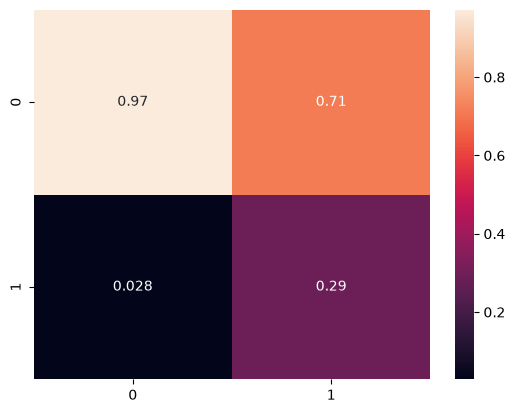

In [18]:
dt.fit(X_train, y_train)

evaluate_models(dt, X_test, y_test)

F1: 0.43163219147098736
Recall: 0.7958750379132544
Precison: 0.2961123963211646


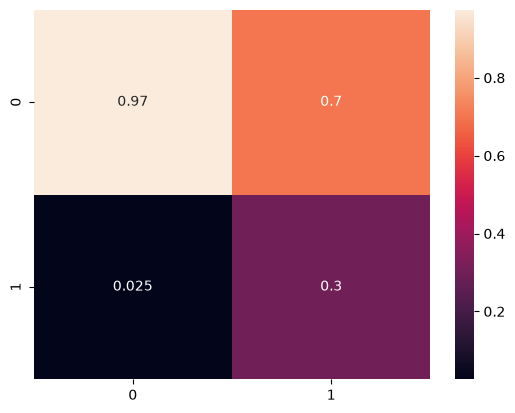

In [19]:
evaluate_models(dt, X_train, y_train)

## Otimização da árvore de decisão

In [20]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv_grid = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

modelo_dt = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    "max_depth": [3, 5, 7, None],
    "criterion": ["gini", "entropy", "log_loss"],
    "splitter": ["best", "random"],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "class_weight": [None, "balanced"],
}

grid_dt = GridSearchCV(
    estimator=modelo_dt,
    param_grid=param_grid_dt,
    scoring="f1_macro",
    cv=cv_grid,
    n_jobs=-1,
    refit=True,
    error_score="raise",
)

grid_dt.fit(X_train, y_train)

print("Melhor F1 macro — árvore:", grid_dt.best_score_)
print("Melhores parâmetros — árvore:", grid_dt.best_params_)


KeyboardInterrupt: 

## Otimização da Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
)

param_grid_rf = {
    "n_estimators": [100, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "class_weight": [None, "balanced", "balanced_subsample"],
}

grid_rf = GridSearchCV(
    estimator=modelo_rf,
    param_grid=param_grid_rf,
    scoring="f1_macro",
    cv=cv_grid,
    n_jobs=-1,
    refit=True,
    error_score="raise",
)

grid_rf.fit(X_train, y_train)

print("Melhor F1 macro — Random Forest:", grid_rf.best_score_)
print("Melhores parâmetros — Random Forest:", grid_rf.best_params_)


## Avaliação dos modelos base

In [ ]:
print("== Árvore de decisão — treino ==")
evaluate_models(grid_dt, X_train, y_train)

print("== Árvore de decisão — teste ==")
evaluate_models(grid_dt, X_test, y_test)

In [ ]:
print("== Random Forest — treino ==")
evaluate_models(grid_rf, X_train, y_train)

print("== Random Forest — teste ==")
evaluate_models(grid_rf, X_test, y_test)

## XGBoost com Optuna

In [ ]:
import seaborn as sns

y_train.value_counts(normalize=False)

In [ ]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

UNDERSAMPLING = False

if UNDERSAMPLING:
    positive_lines = y_train[y_train == 1]

    idx_negative_lines = y_train[y_train == 0].sample(len(positive_lines) * 2).index.to_list()

    idx_sample = idx_negative_lines + positive_lines.index.to_list()

    X_train_sample = X_train.loc[idx_sample]
    y_train_sample = y_train.loc[idx_sample]

else:
    X_train_sample = X_train
    y_train_sample = y_train


# Peso para lidar com o desbalanceamento entre quem tem e quem não tem diagnóstico.
proporcao_desbalanceamento = (y_train == 0).sum() / (y_train == 1).sum()

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 10, 800),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1, proporcao_desbalanceamento),
        "random_state": 42,
        "eval_metric": "logloss",
        "n_jobs": -1,
    }

    modelo = XGBClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(modelo, X_train_sample, y_train_sample, cv=cv, scoring="f1_macro", n_jobs=-1)

    return scores.mean()


study = optuna.create_study(direction="maximize", 
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)

print("Melhor F1 macro (validação cruzada):", study.best_value)
print("Melhores hiperparâmetros:", study.best_params)


In [ ]:
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout()
plt.show()

optuna.visualization.matplotlib.plot_param_importances(study)
plt.tight_layout()
plt.show()

In [ ]:
melhores_params = dict(study.best_params)
melhores_params.update({"random_state": 42, "eval_metric": "logloss", "n_jobs": -1})

xgb_final = XGBClassifier(**melhores_params)
xgb_final.fit(X_train, y_train)

print("== Desempenho no treino ==")
evaluate_models(xgb_final, X_train, y_train)

In [ ]:
print("== Desempenho no teste ==")
evaluate_models(xgb_final, X_test, y_test)

In [ ]:
importancias = pd.DataFrame({
    "Variável": X_train.columns,
    "Importância": xgb_final.feature_importances_,
}).sort_values(
    "Importância",
    ascending=False
).reset_index(drop=True)

plt.figure(figsize=(10, 10))

importancias.head(30).sort_values("Importância").plot(
    kind="barh",
    x="Variável",
    y="Importância",
    legend=False,
    color="tomato",
    ax=plt.gca()
)

plt.title("Importância das variáveis - XGBoost")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

## Visualização dos dados com t-SNE

In [ ]:
import numpy as np
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


# Usa uma amostra estratificada para reduzir o custo
# e manter a proporção entre as classes.
if len(X_test) > 3000:
    _, X_tsne_amostra, _, y_tsne_amostra = train_test_split(
        X_test,
        y_test,
        test_size=3000,
        random_state=42,
        stratify=y_test,
    )
else:
    X_tsne_amostra = X_test.copy()
    y_tsne_amostra = y_test.copy()


# Todas as colunas são tratadas juntas.
# A padronização é aprendida somente com o treino.
escalonador_tsne = StandardScaler()

escalonador_tsne.fit(X_train)

X_tsne_preparado = escalonador_tsne.transform(
    X_tsne_amostra
)


perplexidade_tsne = min(
    30,
    max(2, (len(X_tsne_amostra) - 1) // 3),
)


X_embedded = TSNE(
    n_components=2,
    learning_rate="auto",
    init="pca",
    perplexity=perplexidade_tsne,
    random_state=42,
).fit_transform(X_tsne_preparado)


sns.scatterplot(
    x=X_embedded[:, 0],
    y=X_embedded[:, 1],
    hue=np.asarray(y_tsne_amostra).ravel(),
    palette="Set1",
    alpha=0.7,
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Visualização t-SNE por classe")
plt.legend(title="Classe")
plt.tight_layout()
plt.show()


# Modelos adicionais

In [ ]:
import optuna
from lightgbm import LGBMClassifier

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Mesmas divisões para os dois modelos, garantindo comparação justa.
cv_adicional = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42,
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("Distribuição no treino:")
display(y_train.value_counts().sort_index())


## LightGBM com Optuna

In [ ]:
def objective_lgbm(trial):
    parametros = {
        "objective": "binary",
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.20, log=True
        ),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int(
            "min_child_samples", 10, 100
        ),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.60, 1.00
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-8, 10.0, log=True
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-8, 10.0, log=True
        ),
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1,
    }

    modelo = LGBMClassifier(**parametros)

    resultados = cross_val_score(
        modelo,
        X_train,
        y_train,
        cv=cv_adicional,
        scoring="average_precision",
        n_jobs=1,
    )

    return resultados.mean()


study_lgbm = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name="lightgbm_depressao",
)

study_lgbm.optimize(
    objective_lgbm,
    n_trials=30,
    show_progress_bar=True,
)

print("Melhor PR-AUC médio na validação:", study_lgbm.best_value)
print("Melhores parâmetros:")
display(study_lgbm.best_params)


In [ ]:
parametros_lgbm = dict(study_lgbm.best_params)
parametros_lgbm.update({
    "objective": "binary",
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1,
    "subsample_freq": 1,
})

lgbm_final = LGBMClassifier(**parametros_lgbm)
lgbm_final.fit(X_train, y_train)

print("LightGBM treinado.")


## SVM 

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score


def criar_pipeline_svm(C):
    return Pipeline([
        (
            "padronizacao",
            StandardScaler(),
        ),
        (
            "svm",
            LinearSVC(
                C=C,
                class_weight="balanced",
                dual=False,
                max_iter=20000,
                random_state=42,
            ),
        ),
    ])


def objective_svm(trial):
    C = trial.suggest_float(
        "C",
        1e-4,
        100.0,
        log=True,
    )

    modelo = criar_pipeline_svm(C)

    resultados = cross_val_score(
        modelo,
        X_train,
        y_train,
        cv=cv_adicional,
        scoring="average_precision",
        n_jobs=-1,
    )

    return resultados.mean()


study_svm = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name="svm_depressao",
)


study_svm.optimize(
    objective_svm,
    n_trials=20,
    show_progress_bar=True,
)


print(
    "Melhor PR-AUC médio na validação:",
    study_svm.best_value,
)

print("Melhor parâmetro:")
display(study_svm.best_params)

In [ ]:
svm_base = criar_pipeline_svm(study_svm.best_params["C"])

# Compatibilidade com versões novas e antigas do scikit-learn.
try:
    svm_final = CalibratedClassifierCV(
        estimator=svm_base,
        method="sigmoid",
        cv=3,
        n_jobs=-1,
    )
except TypeError:
    svm_final = CalibratedClassifierCV(
        base_estimator=svm_base,
        method="sigmoid",
        cv=3,
        n_jobs=-1,
    )

svm_final.fit(X_train, y_train)

print("SVM calibrado treinado.")


## Avaliação dos modelos adicionais

In [ ]:
def avaliar_modelo_adicional(nome, modelo, X_avaliacao, y_avaliacao):
    previsoes = modelo.predict(X_avaliacao)
    probabilidades = modelo.predict_proba(X_avaliacao)[:, 1]

    metricas = {
        "Modelo": nome,
        "PR-AUC": average_precision_score(
            y_avaliacao, probabilidades
        ),
        "ROC-AUC": roc_auc_score(
            y_avaliacao, probabilidades
        ),
        "Balanced accuracy": balanced_accuracy_score(
            y_avaliacao, previsoes
        ),
        "F1 macro": f1_score(
            y_avaliacao, previsoes, average="macro"
        ),
        "Recall macro": recall_score(
            y_avaliacao, previsoes, average="macro"
        ),
        "Precisão macro": precision_score(
            y_avaliacao, previsoes, average="macro", zero_division=0
        ),
        "F1 classe 1": f1_score(
            y_avaliacao, previsoes, pos_label=1
        ),
        "Recall classe 1": recall_score(
            y_avaliacao, previsoes, pos_label=1
        ),
        "Precisão classe 1": precision_score(
            y_avaliacao, previsoes, pos_label=1, zero_division=0
        ),
    }

    matriz = confusion_matrix(
        y_avaliacao,
        previsoes,
        normalize="true",
    )

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        matriz,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        vmin=0,
        vmax=1,
    )
    plt.title(f"Matriz de confusão normalizada — {nome}")
    plt.xlabel("Classe prevista")
    plt.ylabel("Classe verdadeira")
    plt.tight_layout()
    plt.show()

    return metricas


resultados_adicionais = []

resultados_adicionais.append(
    avaliar_modelo_adicional(
        "LightGBM", lgbm_final, X_test, y_test
    )
)

resultados_adicionais.append(
    avaliar_modelo_adicional(
        "SVM linear calibrado", svm_final, X_test, y_test
    )
)

comparacao_adicional = (
    pd.DataFrame(resultados_adicionais)
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)

display(comparacao_adicional)


## Comparação geral dos modelos

In [ ]:
modelos_para_comparar = {
    "Árvore de decisão": grid_dt,
    "Random Forest": grid_rf,
    "LightGBM": lgbm_final,
    "SVM linear calibrado": svm_final,
}

if "xgb_final" in globals():
    modelos_para_comparar["XGBoost"] = xgb_final

linhas_comparacao = []

for nome, modelo in modelos_para_comparar.items():
    try:
        pred = modelo.predict(X_test)
        prob = modelo.predict_proba(X_test)[:, 1]

        linhas_comparacao.append({
            "Modelo": nome,
            "PR-AUC": average_precision_score(y_test, prob),
            "ROC-AUC": roc_auc_score(y_test, prob),
            "Balanced accuracy": balanced_accuracy_score(y_test, pred),
            "F1 macro": f1_score(y_test, pred, average="macro"),
            "Recall classe 1": recall_score(y_test, pred, pos_label=1),
            "Precisão classe 1": precision_score(
                y_test, pred, pos_label=1, zero_division=0
            ),
        })
    except Exception as erro:
        print(f"Não foi possível avaliar {nome}: {erro}")

comparacao_geral = (
    pd.DataFrame(linhas_comparacao)
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)

display(comparacao_geral)



# Explicabilidade com SHAP

In [ ]:
import shap

pontuacoes_validacao_adicionais = {
    "LightGBM": study_lgbm.best_value,
    "SVM linear calibrado": study_svm.best_value,
}

nome_melhor_adicional = max(
    pontuacoes_validacao_adicionais,
    key=pontuacoes_validacao_adicionais.get,
)

print(
    "Modelo selecionado para o SHAP pela validação cruzada:",
    nome_melhor_adicional,
)

if nome_melhor_adicional == "LightGBM":
    modelo_shap = lgbm_final
    amostra_shap = X_test.sample(
        n=min(1000, len(X_test)),
        random_state=42,
    )

    explicador = shap.TreeExplainer(modelo_shap)
    valores_shap = explicador(amostra_shap)

    # Algumas versões retornam uma dimensão separada para cada classe.
    if len(valores_shap.values.shape) == 3:
        valores_shap = valores_shap[:, :, 1]

else:
    modelo_shap = svm_final

    fundo_shap = X_train.sample(
        n=min(60, len(X_train)),
        random_state=42,
    )
    amostra_shap = X_test.sample(
        n=min(80, len(X_test)),
        random_state=42,
    )

    def prever_classe_positiva(dados_recebidos):
        dados_recebidos = pd.DataFrame(
            dados_recebidos,
            columns=X_train.columns,
        )
        return modelo_shap.predict_proba(dados_recebidos)[:, 1]

    explicador = shap.Explainer(
        prever_classe_positiva,
        fundo_shap,
        feature_names=list(X_train.columns),
        algorithm="permutation",
    )

    valores_shap = explicador(
        amostra_shap,
        max_evals=2 * X_train.shape[1] + 1,
    )


## Importância global e distribuição dos efeitos

In [ ]:
# Importância global média das variáveis.
shap.plots.bar(
    valores_shap,
    max_display=25,
    show=False,
)
plt.title(f"Importância global SHAP — {nome_melhor_adicional}")
plt.tight_layout()
plt.show()

# Distribuição dos efeitos positivos e negativos nas previsões.
shap.plots.beeswarm(
    valores_shap,
    max_display=25,
    show=False,
)
plt.title(f"Resumo SHAP — {nome_melhor_adicional}")
plt.tight_layout()
plt.show()


## Explicação de uma observação individual

In [ ]:
# Explicação de uma observação individual da amostra.
indice_exemplo = 0

shap.plots.waterfall(
    valores_shap[indice_exemplo],
    max_display=20,
    show=False,
)
plt.title(
    f"Explicação individual — {nome_melhor_adicional}"
)
plt.tight_layout()
plt.show()